In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ai_worker_burnout_attrition_2026.csv')
df.head(10)

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium
5,EMP0006,Data Analyst,12,Self-taught,Germany,Healthtech,Large (1000-5000),On-site,19,106,...,5,5.7,23,Optimizing,6.7,66,61,3.5,Medium,Low
6,EMP0007,AI Ethics Officer,12,PhD,USA,Gaming,Enterprise (5000+),Fully Remote,46,154,...,1,2.7,45,Optimizing,8.1,54,33,3.5,High,Low
7,EMP0008,Data Scientist,19,Bootcamp,Singapore,Consulting,Enterprise (5000+),Hybrid,44,54,...,7,4.7,46,Optimizing,9.1,43,57,2.9,Low,Medium
8,EMP0009,Data Analyst,6,Master,Germany,Fintech,Mid (200-1000),Hybrid,42,55,...,7,2.8,56,Experimenting,8.1,69,52,2.8,Low,Medium
9,EMP0010,Prompt Engineer,2,Bachelor,Netherlands,Gaming,Large (1000-5000),On-site,15,61,...,5,1.8,8,Optimizing,9.7,64,27,3.8,Medium,Low


In [4]:
df.dtypes

employee_id                        object
job_role                           object
years_experience                    int64
education_level                    object
country                            object
industry                           object
company_size                       object
remote_work_type                   object
team_size                           int64
salary_usd_k                        int64
primary_ai_tool                    object
ai_tools_used_per_day               int64
hours_with_ai_assistance_daily    float64
ai_replaces_my_tasks_pct            int64
ai_adoption_stage                  object
weekly_ai_upskilling_hrs          float64
productivity_score                  int64
burnout_score                       int64
job_satisfaction_1_5              float64
fear_of_ai_replacement             object
attrition_risk                     object
dtype: object

In [5]:
nominal_cats = [
    "job_role", "education_level", "country",
    "industry", "company_size", "remote_work_type", "primary_ai_tool",
]
for col in nominal_cats:
    df[col] = df[col].astype("category")

In [6]:
df["fear_of_ai_replacement"] = pd.Categorical(
    df["fear_of_ai_replacement"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)
df["attrition_risk"] = pd.Categorical(
    df["attrition_risk"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)
df["ai_adoption_stage"] = pd.Categorical(
    df["ai_adoption_stage"],
    categories=["Experimenting", "Integrating", "Optimizing", "AI-First"],
    ordered=True,
)

In [7]:
df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [8]:
df.dtypes

employee_id                         object
job_role                          category
years_experience                     int64
education_level                   category
country                           category
industry                          category
company_size                      category
remote_work_type                  category
team_size                            int64
salary_usd_k                         int64
primary_ai_tool                   category
ai_tools_used_per_day                int64
hours_with_ai_assistance_daily     float64
ai_replaces_my_tasks_pct             int64
ai_adoption_stage                 category
weekly_ai_upskilling_hrs           float64
productivity_score                   int64
burnout_score                        int64
job_satisfaction_1_5               float64
fear_of_ai_replacement            category
attrition_risk                    category
dtype: object

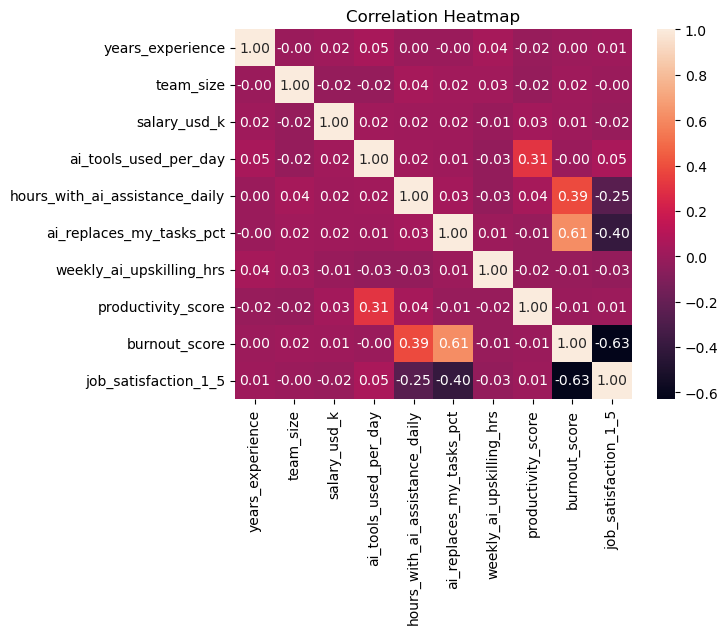

In [23]:
plt.figure()
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Burnout by Remote Work Type

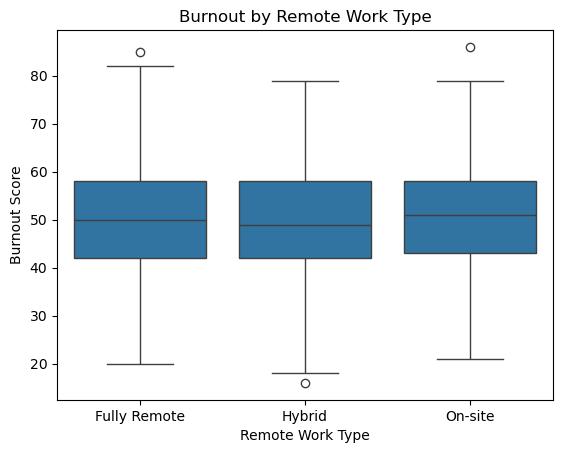

In [12]:
plt.figure()
sns.boxplot(x="remote_work_type", y="burnout_score", data=df)
plt.title("Burnout by Remote Work Type")
plt.xlabel("Remote Work Type")
plt.ylabel("Burnout Score")
plt.show()

### AI Replacing Tasks vs Burnout

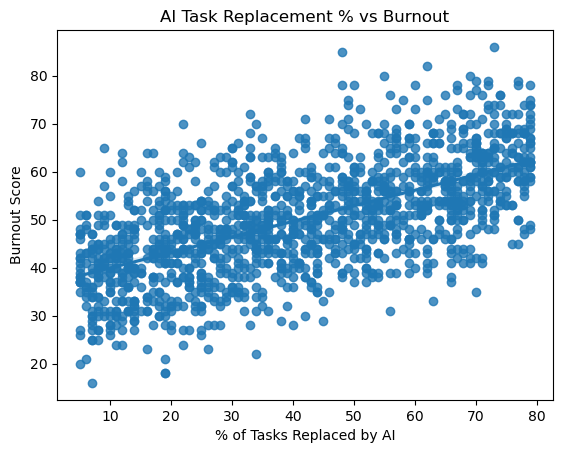

In [13]:
plt.figure()
sns.regplot(x="ai_replaces_my_tasks_pct", y="burnout_score", data=df)
plt.title("AI Task Replacement % vs Burnout")
plt.xlabel("% of Tasks Replaced by AI")
plt.ylabel("Burnout Score")
plt.show()

### Daily AI Hours vs Burnout

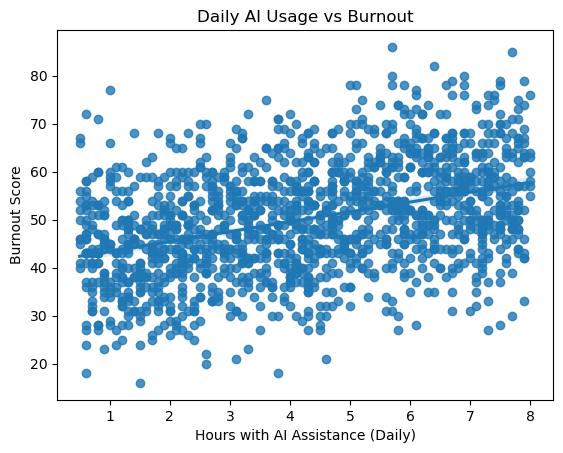

In [14]:
plt.figure()
sns.regplot(x="hours_with_ai_assistance_daily", y="burnout_score", data=df)
plt.title("Daily AI Usage vs Burnout")
plt.xlabel("Hours with AI Assistance (Daily)")
plt.ylabel("Burnout Score")
plt.show()

### AI Upskilling vs Burnout

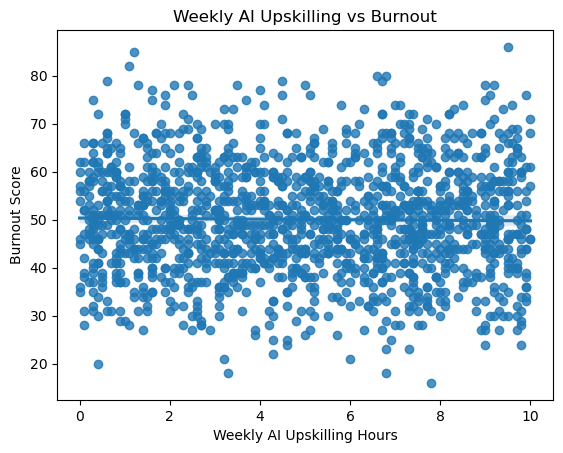

In [15]:
plt.figure()
sns.regplot(x="weekly_ai_upskilling_hrs", y="burnout_score", data=df)
plt.title("Weekly AI Upskilling vs Burnout")
plt.xlabel("Weekly AI Upskilling Hours")
plt.ylabel("Burnout Score")
plt.show()

### Fear of AI Replacement vs Burnout

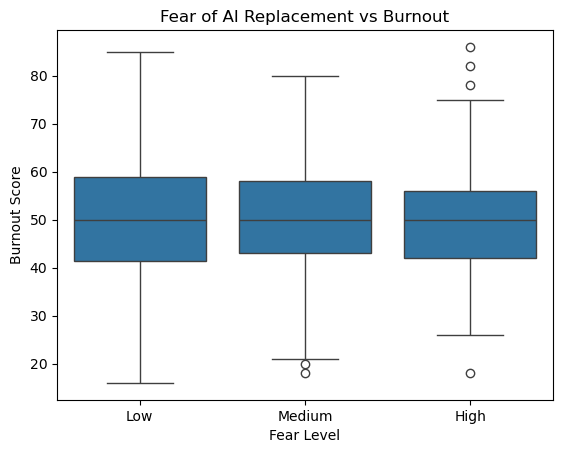

In [16]:
plt.figure()
sns.boxplot(x="fear_of_ai_replacement", y="burnout_score", data=df)
plt.title("Fear of AI Replacement vs Burnout")
plt.xlabel("Fear Level")
plt.ylabel("Burnout Score")
plt.show()

### Burnout vs Attrition Risk

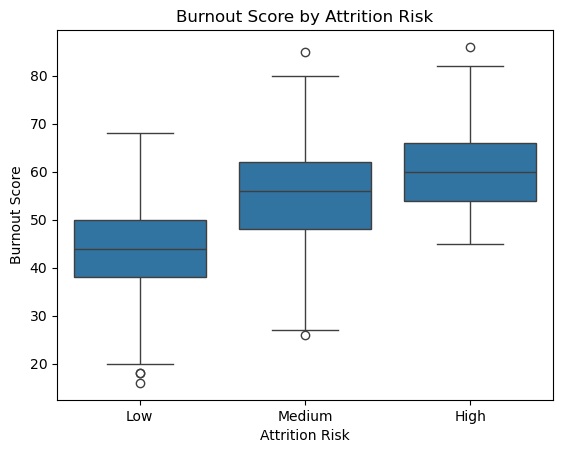

In [22]:
plt.figure()
sns.boxplot(x="attrition_risk", y="burnout_score", data=df)
plt.title("Burnout Score by Attrition Risk")
plt.xlabel("Attrition Risk")
plt.ylabel("Burnout Score")
plt.show()

### Productivity vs Burnout

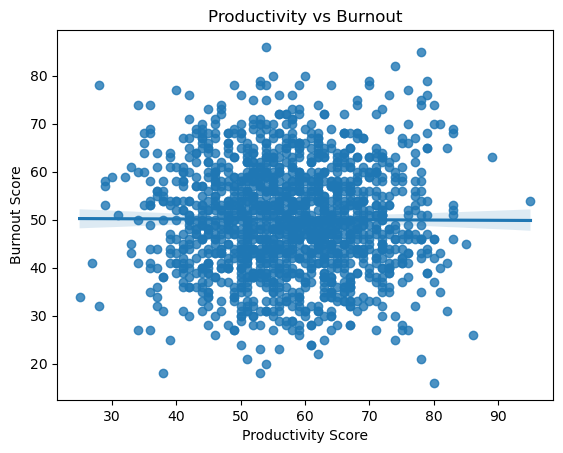

In [18]:
plt.figure()
sns.regplot(x="productivity_score", y="burnout_score", data=df)
plt.title("Productivity vs Burnout")
plt.xlabel("Productivity Score")
plt.ylabel("Burnout Score")
plt.show()

### Productivity vs Attrition Risk

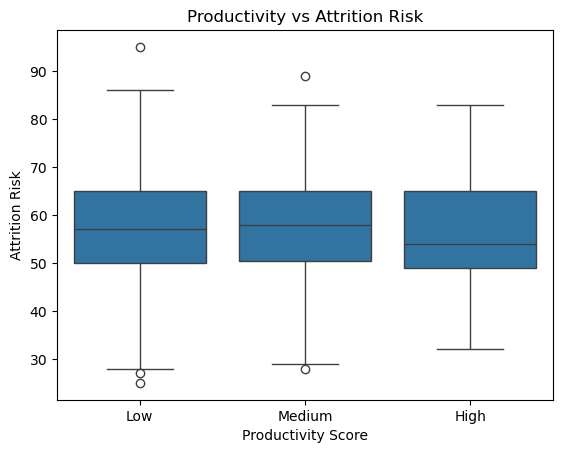

In [21]:
plt.figure()
sns.boxplot(x="attrition_risk", y="productivity_score", data=df)
plt.title("Productivity vs Attrition Risk")
plt.xlabel("Productivity Score")
plt.ylabel("Attrition Risk")
plt.show()

### Job Satisfaction vs Burnout

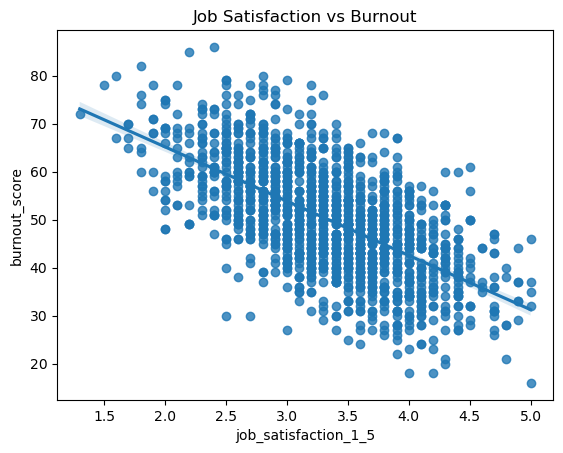

In [26]:
plt.figure()
sns.regplot(x="job_satisfaction_1_5", y="burnout_score", data=df)
plt.title("Job Satisfaction vs Burnout")
plt.show()